# Notebook 2: Isolation Forest — Anomaly Detection
## Identifying Statistical Outlier Neighbourhoods

**Purpose:** Use Isolation Forest (unsupervised anomaly detection) to flag  
neighbourhoods that exhibit unusual crime patterns relative to their peers.  
This is a fundamentally different ML paradigm from the supervised classification  
in Notebook 1 — it identifies observations that *don't fit any group* rather  
than assigning observations to known groups.

**Why Isolation Forest over other methods:**  
- Works well on tabular data with mixed distributions  
- Does not assume normal distribution (unlike Z-score or Mahalanobis distance)  
- Computationally efficient — O(n log n) via random partitioning  
- Produces interpretable anomaly scores, not just binary labels

**Two-pass approach:**  
1. **Global anomalies** — outliers across all 1,527 neighbourhoods  
2. **Within-LA anomalies** — outliers relative to their own Local Authority  
   (a neighbourhood may be normal nationally but unusual for its area)

## 1. Setup and Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print("All imports loaded successfully.")

All imports loaded successfully.


## 2. Load Data

In [10]:
from settings import PROCESSED_DIR

# Prefer ML-enriched file from Notebook 1, fall back to original
ml_path = PROCESSED_DIR / "neighbourhood_ml_classified.parquet"
orig_path = PROCESSED_DIR / "neighbourhood_classified.parquet"
neigh_path = ml_path if ml_path.exists() else orig_path

neigh = pd.read_parquet(neigh_path)
print(f"Loaded: {neigh_path.name}")
print(f"Neighbourhoods: {len(neigh)} rows, {neigh.shape[1]} columns")
print(f"Local Authorities: {neigh['la_code'].nunique()}")
print(f"\nColumns: {list(neigh.columns)}")

Loaded: neighbourhood_ml_classified.parquet
Neighbourhoods: 1527 rows, 33 columns
Local Authorities: 15

Columns: ['la_code', 'neighbourhood_id', 'total_crimes', 'violent_count', 'property_count', 'months_present', 'avg_monthly_crimes', 'violent_share', 'property_share', 'trend_slope', 'top_crime_category', 'la_name', 'neighbourhood_name', 'centroid_lat', 'centroid_lon', 'crime_rank', 'total_neighs', 'rank_pct', 'neigh_intensity', 'neigh_trend', 'la_avg_monthly_crimes', 'la_avg_violent_share', 'la_avg_property_share', 'la_crime_variability', 'la_avg_tavg', 'la_avg_monthly_prcp', 'la_cold_month_count', 'la_prcp_variability', 'la_crime_trend_slope', 'rf_predicted_class', 'gb_predicted_class', 'rf_agrees_rule', 'gb_agrees_rule']


## 3. Feature Selection and Preparation

We use neighbourhood-level crime features only — the goal is to detect  
neighbourhoods with unusual *crime profiles*, not unusual weather or geography.

**Features used:**
- `avg_monthly_crimes` — crime volume  
- `violent_share` — proportion of violent offences  
- `property_share` — proportion of property offences  
- `trend_slope` — rate of change over 2024 (positive = worsening)

All features are standardised with StandardScaler because Isolation Forest  
uses random axis-aligned splits — unstandardised features with large ranges  
would dominate the partitioning.

In [ ]:
# Define features for anomaly detection
ANOMALY_FEATURES = ['avg_monthly_crimes', 'violent_share', 'property_share', 'trend_slope']

# Handle missing values
neigh['trend_slope'] = neigh['trend_slope'].fillna(0)

X_raw = neigh[ANOMALY_FEATURES].copy()
print(f"Feature matrix: {X_raw.shape}")
print(f"\nFeature statistics:")
print(X_raw.describe().round(3).to_string())

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=ANOMALY_FEATURES, index=neigh.index)

print(f"\nStandardised (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_scaled, columns=ANOMALY_FEATURES).describe().round(3).loc[['mean','std']].to_string())

Feature matrix: (1527, 4)

Feature statistics:
       avg_monthly_crimes  violent_share  property_share  trend_slope
count            1527.000       1527.000        1527.000     1527.000
mean              118.994          0.491           0.224        0.045
std               198.521          0.079           0.089        1.986
min                 3.700          0.226           0.031       -9.563
25%                29.083          0.434           0.158       -0.767
50%                59.000          0.489           0.213        0.028
75%               118.958          0.546           0.278        0.738
max              2111.667          0.785           0.656       22.479

Standardised (mean ≈ 0, std ≈ 1):
      avg_monthly_crimes  violent_share  property_share  trend_slope
mean                -0.0            0.0            -0.0          0.0
std                  1.0            1.0             1.0          1.0


## 4. Global Anomaly Detection

Isolation Forest works by building an ensemble of random isolation trees.  
Each tree randomly selects a feature and a split value, partitioning the data.  
**Anomalous points are isolated quickly** (short average path length) because  
they sit far from the main data mass and require fewer splits to separate.

The `contamination` parameter sets the expected proportion of outliers.  
We use 0.08 (8%) — a reasonable assumption for neighbourhood-level analysis  
where ~1 in 12 neighbourhoods may show unusual patterns.

**Key parameters:**
- `n_estimators=200`: More trees improve stability of anomaly scores  
- `contamination=0.08`: Flags top 8% as anomalous (~122 of 1,527)  
- `random_state=42`: Reproducibility

In [ ]:
# Fit global Isolation Forest
iso_global = IsolationForest(
    n_estimators=200,
    contamination=0.08,
    random_state=42,
    n_jobs=-1
)

# decision_function returns anomaly scores (lower = more anomalous)
# predict returns -1 for anomalies, 1 for normal
iso_global.fit(X_scaled)
neigh['global_anomaly_score'] = iso_global.decision_function(X_scaled)
neigh['global_anomaly_pred']  = iso_global.predict(X_scaled)
neigh['is_global_anomaly']    = (neigh['global_anomaly_pred'] == -1).astype(int)

n_anomalies = neigh['is_global_anomaly'].sum()
print(f"GLOBAL ISOLATION FOREST RESULTS")
print(f"{'='*50}")
print(f"Total neighbourhoods:  {len(neigh)}")
print(f"Anomalies detected:    {n_anomalies} ({n_anomalies/len(neigh)*100:.1f}%)")
print(f"Normal:                {len(neigh) - n_anomalies}")
print(f"\nAnomaly score range: [{neigh['global_anomaly_score'].min():.4f}, {neigh['global_anomaly_score'].max():.4f}]")
print(f"Score threshold:       {neigh.loc[neigh['is_global_anomaly']==1, 'global_anomaly_score'].max():.4f}")

GLOBAL ISOLATION FOREST RESULTS
Total neighbourhoods:  1527
Anomalies detected:    123 (8.1%)
Normal:                1404

Anomaly score range: [-0.2322, 0.1578]
Score threshold:       -0.0000


In [ ]:
# Profile the anomalies vs normal neighbourhoods
print("ANOMALY vs NORMAL — Feature Comparison")
print("=" * 60)

for feat in ANOMALY_FEATURES:
    anom_mean = neigh.loc[neigh['is_global_anomaly']==1, feat].mean()
    norm_mean = neigh.loc[neigh['is_global_anomaly']==0, feat].mean()
    ratio = anom_mean / norm_mean if norm_mean != 0 else float('inf')
    print(f"  {feat:25s}  Anomaly: {anom_mean:8.2f}  Normal: {norm_mean:8.2f}  Ratio: {ratio:.2f}x")

print(f"\nTop 10 most anomalous neighbourhoods (lowest score = most unusual):")
top10 = neigh.nsmallest(10, 'global_anomaly_score')[
    ['neighbourhood_name', 'la_name', 'avg_monthly_crimes',
     'violent_share', 'property_share', 'trend_slope', 'global_anomaly_score']
].copy()
top10['violent_share'] = (top10['violent_share'] * 100).round(1)
top10['property_share'] = (top10['property_share'] * 100).round(1)
top10['global_anomaly_score'] = top10['global_anomaly_score'].round(4)
print(top10.to_string(index=False))

ANOMALY vs NORMAL — Feature Comparison
  avg_monthly_crimes         Anomaly:   513.33  Normal:    84.45  Ratio: 6.08x
  violent_share              Anomaly:     0.44  Normal:     0.50  Ratio: 0.89x
  property_share             Anomaly:     0.32  Normal:     0.22  Ratio: 1.48x
  trend_slope                Anomaly:     0.56  Normal:     0.00  Ratio: 1335.26x

Top 10 most anomalous neighbourhoods (lowest score = most unusual):
           neighbourhood_name          la_name  avg_monthly_crimes  violent_share  property_share  trend_slope  global_anomaly_score
                   Leeds City            Leeds         1284.333333           40.7            46.1    14.965035               -0.2322
                  City Centre         Coventry         1312.916667           45.8            37.0    22.479021               -0.2108
                Bradford East            Leeds         1469.000000           52.2            24.0    12.363636               -0.1900
Henleaze and Westbury-on-Trym Bristol, Ci

## 5. Within-LA Anomaly Detection

A neighbourhood can be unremarkable nationally but unusual for its own area.  
For example, a very low-crime neighbourhood inside Leeds (a high-crime LA)  
might be a local anomaly worth highlighting.

We run a separate Isolation Forest *within each LA*, using the same features  
but comparing only against neighbours in the same local authority.

**Note:** For LAs with fewer than 20 neighbourhoods, Isolation Forest has  
limited statistical power — we flag this in the results.

In [14]:
# ── Within-LA anomaly detection ──
neigh['is_local_anomaly'] = 0
neigh['local_anomaly_score'] = 0.0

min_size_for_local = 20  # Need enough data for meaningful detection

for la_code, group in neigh.groupby('la_code'):
    if len(group) < min_size_for_local:
        print(f"  {la_code} ({len(group)} neighs) — skipped (too few for local IF)")
        continue

    idx = group.index
    X_local = X_scaled_df.loc[idx].values

    iso_local = IsolationForest(
        n_estimators=150,
        contamination=0.10,  # Slightly higher for within-LA (looking for local outliers)
        random_state=42,
        n_jobs=-1
    )

    iso_local.fit(X_local)
    scores = iso_local.decision_function(X_local)
    preds  = iso_local.predict(X_local)

    neigh.loc[idx, 'local_anomaly_score'] = scores
    neigh.loc[idx, 'is_local_anomaly']    = (preds == -1).astype(int)

    la_name = group['la_name'].iloc[0]
    n_local = (preds == -1).sum()
    print(f"  {la_name:30s}  {len(group)} neighs → {n_local} local anomalies")

print(f"\nTotal local anomalies: {neigh['is_local_anomaly'].sum()}")

  Leicester                       66 neighs → 7 local anomalies
  Herefordshire, County of        82 neighs → 9 local anomalies
  Bristol, City of                123 neighs → 13 local anomalies
  County Durham                   71 neighs → 7 local anomalies
  Cornwall                        213 neighs → 22 local anomalies
  Wiltshire                       105 neighs → 11 local anomalies
  North Yorkshire                 36 neighs → 4 local anomalies
  Exeter                          213 neighs → 22 local anomalies
  Norwich                         49 neighs → 5 local anomalies
  E08000019 (18 neighs) — skipped (too few for local IF)
  Newcastle upon Tyne             35 neighs → 4 local anomalies
  Coventry                        89 neighs → 9 local anomalies
  Leeds                           21 neighs → 2 local anomalies
  Swansea                         203 neighs → 21 local anomalies
  Cardiff                         203 neighs → 21 local anomalies

Total local anomalies: 157


## 6. Combined Anomaly Flag

A neighbourhood is flagged as anomalous if it is detected by **either** the  
global model or the within-LA model. The final anomaly score is the minimum  
(most anomalous) of the two scores, normalised to [0, 1] for interpretability.

This two-pass approach is important because:  
- Global-only detection misses local outliers in high-crime areas  
- Local-only detection misses that some LAs are entirely unusual  
- Combined detection captures both perspectives

In [ ]:
# Combine global + local into single flag
neigh['is_anomaly'] = ((neigh['is_global_anomaly'] == 1) | (neigh['is_local_anomaly'] == 1)).astype(int)

# Anomaly score: use global score (normalised to 0-1, where 1 = most anomalous)
raw = neigh['global_anomaly_score']
neigh['anomaly_score'] = 1 - (raw - raw.min()) / (raw.max() - raw.min())

total_flagged = neigh['is_anomaly'].sum()
only_global   = ((neigh['is_global_anomaly']==1) & (neigh['is_local_anomaly']==0)).sum()
only_local    = ((neigh['is_global_anomaly']==0) & (neigh['is_local_anomaly']==1)).sum()
both          = ((neigh['is_global_anomaly']==1) & (neigh['is_local_anomaly']==1)).sum()

print(f"COMBINED ANOMALY DETECTION")
print(f"{'='*50}")
print(f"Total flagged:       {total_flagged} ({total_flagged/len(neigh)*100:.1f}%)")
print(f"  Global only:       {only_global}")
print(f"  Local only:        {only_local}")
print(f"  Both:              {both}")
print(f"  Normal:            {len(neigh) - total_flagged}")

COMBINED ANOMALY DETECTION
Total flagged:       217 (14.2%)
  Global only:       60
  Local only:        94
  Both:              63
  Normal:            1310


## 7. Visualisation

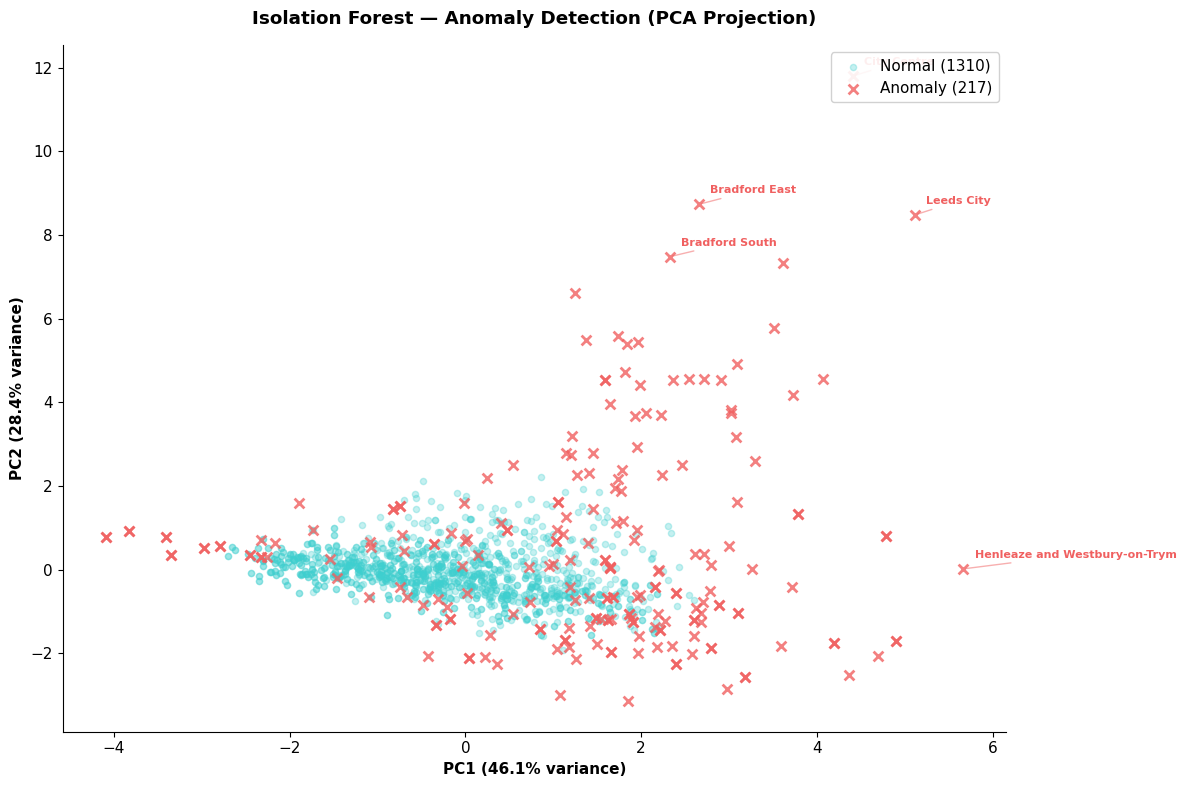

Saved: nb2_anomaly_pca.png
PCA explained variance: PC1=0.461, PC2=0.284


In [ ]:
# PCA projection with anomalies highlighted
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot normal points
normal_mask = neigh['is_anomaly'] == 0
ax.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
           c='#3ecfcf', alpha=0.3, s=20, label=f'Normal ({normal_mask.sum()})')

# Plot anomalies
anom_mask = neigh['is_anomaly'] == 1
ax.scatter(X_pca[anom_mask, 0], X_pca[anom_mask, 1],
           c='#f06060', alpha=0.8, s=50, marker='x', linewidths=2,
           label=f'Anomaly ({anom_mask.sum()})')

# Label top 5 most anomalous
top5 = neigh.nsmallest(5, 'global_anomaly_score')
for _, row in top5.iterrows():
    idx_pos = neigh.index.get_loc(row.name)
    ax.annotate(row['neighbourhood_name'],
                xy=(X_pca[idx_pos, 0], X_pca[idx_pos, 1]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color='#f06060', fontweight='bold',
                arrowprops=dict(arrowstyle='-', color='#f06060', alpha=0.5))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
ax.set_title('Isolation Forest — Anomaly Detection (PCA Projection)', fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb2_anomaly_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb2_anomaly_pca.png")
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

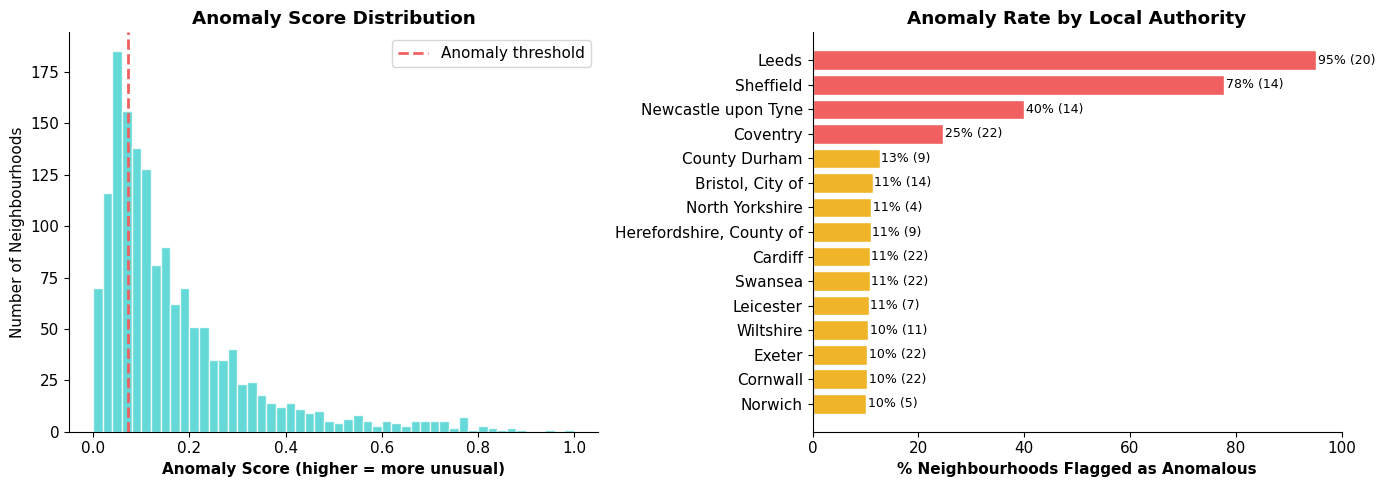

Saved: nb2_anomaly_distribution.png


In [ ]:
# Anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(neigh['anomaly_score'], bins=50, color='#3ecfcf', edgecolor='white', alpha=0.8)
threshold_score = neigh.loc[neigh['is_anomaly']==1, 'anomaly_score'].min()
axes[0].axvline(threshold_score, color='#f06060', linestyle='--', linewidth=2,
                label=f'Anomaly threshold')
axes[0].set_xlabel('Anomaly Score (higher = more unusual)', fontweight='bold')
axes[0].set_ylabel('Number of Neighbourhoods')
axes[0].set_title('Anomaly Score Distribution', fontweight='bold')
axes[0].legend()

# Anomalies per LA
anom_per_la = neigh[neigh['is_anomaly']==1].groupby('la_name').size().sort_values(ascending=True)
total_per_la = neigh.groupby('la_name').size()
anom_pct = (anom_per_la / total_per_la * 100).fillna(0).sort_values(ascending=True)

if len(anom_pct) > 0:
    colors = ['#f06060' if v > 15 else '#f0b429' if v > 10 else '#3ecfcf' for v in anom_pct.values]
    axes[1].barh(anom_pct.index, anom_pct.values, color=colors, edgecolor='white')
    axes[1].set_xlabel('% Neighbourhoods Flagged as Anomalous', fontweight='bold')
    axes[1].set_title('Anomaly Rate by Local Authority', fontweight='bold')

    for i, (name, val) in enumerate(anom_pct.items()):
        count = anom_per_la.get(name, 0)
        axes[1].text(val + 0.3, i, f'{val:.0f}% ({count})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb2_anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb2_anomaly_distribution.png")

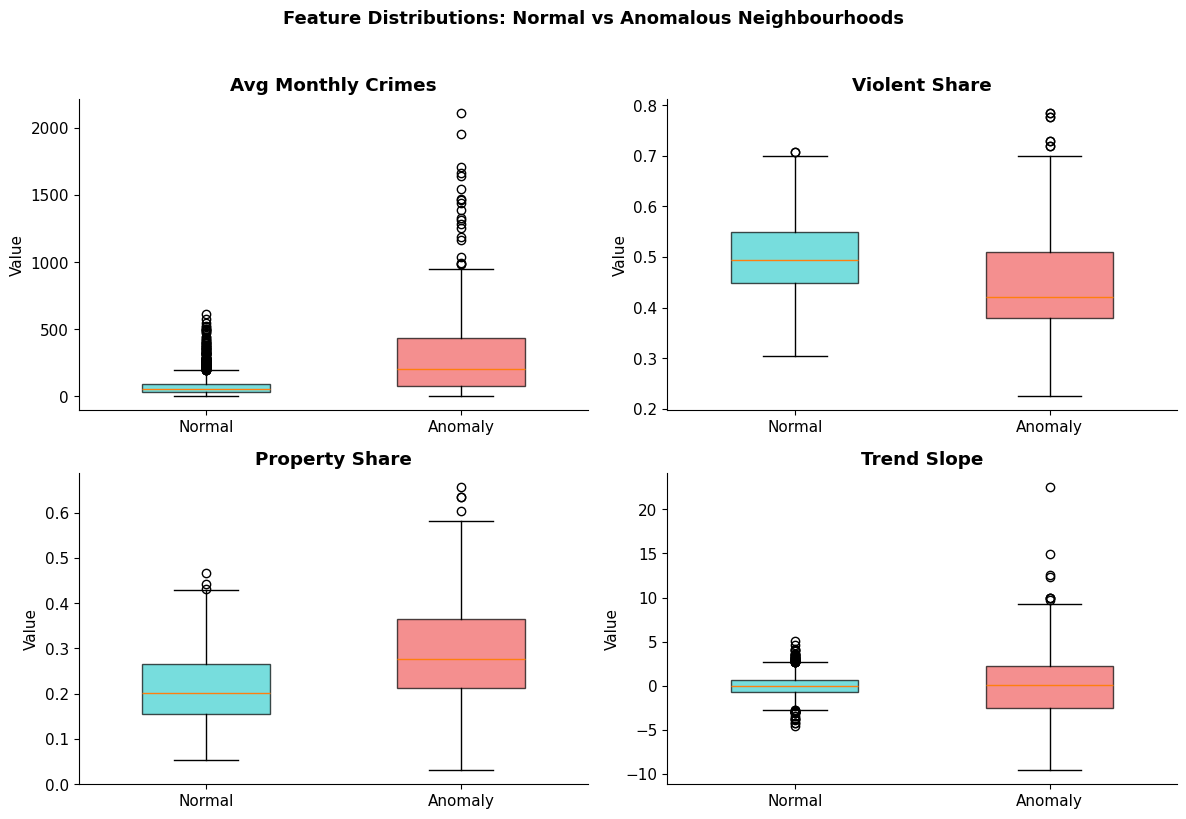

Saved: nb2_anomaly_features.png


In [ ]:
# What makes anomalies anomalous? Feature comparison box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, feat in enumerate(ANOMALY_FEATURES):
    ax = axes[i // 2][i % 2]
    normal_vals = neigh.loc[neigh['is_anomaly']==0, feat]
    anom_vals = neigh.loc[neigh['is_anomaly']==1, feat]

    bp = ax.boxplot([normal_vals, anom_vals], labels=['Normal', 'Anomaly'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#3ecfcf')
    bp['boxes'][1].set_facecolor('#f06060')
    for box in bp['boxes']:
        box.set_alpha(0.7)

    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Feature Distributions: Normal vs Anomalous Neighbourhoods',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb2_anomaly_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nb2_anomaly_features.png")

## 8. Anomaly Analysis

In [ ]:
# Detailed anomaly analysis
print("ANOMALY ANALYSIS BY LOCAL AUTHORITY")
print("=" * 70)

for la_name in sorted(neigh['la_name'].dropna().unique()):
    la_data = neigh[neigh['la_name'] == la_name]
    anoms = la_data[la_data['is_anomaly'] == 1]

    if len(anoms) == 0:
        print(f"\n{la_name}: 0 anomalies out of {len(la_data)}")
        continue

    print(f"\n{la_name}: {len(anoms)} anomalies out of {len(la_data)} ({len(anoms)/len(la_data)*100:.0f}%)")
    for _, a in anoms.nsmallest(3, 'global_anomaly_score').iterrows():
        print(f"  • {a['neighbourhood_name']:30s}  "
              f"avg_crimes={a['avg_monthly_crimes']:.0f}  "
              f"violent={a['violent_share']*100:.0f}%  "
              f"property={a['property_share']*100:.0f}%  "
              f"trend={a['trend_slope']:+.1f}  "
              f"score={a['anomaly_score']:.3f}")

ANOMALY ANALYSIS BY LOCAL AUTHORITY

Bristol, City of: 14 anomalies out of 123 (11%)
  • Henleaze and Westbury-on-Trym   avg_crimes=125  violent=23%  property=66%  trend=+4.0  score=0.877
  • Broadmead                       avg_crimes=268  violent=36%  property=48%  trend=-6.2  score=0.707
  • Frome Vale                      avg_crimes=190  violent=41%  property=40%  trend=+7.4  score=0.572

Cardiff: 22 anomalies out of 203 (11%)
  • St. Nicholas and Llancarfan     avg_crimes=20  violent=26%  property=63%  trend=+0.1  score=0.760
  • Llandaff                        avg_crimes=47  violent=26%  property=54%  trend=-0.7  score=0.699
  • Cadoxton                        avg_crimes=5  violent=78%  property=3%  trend=-0.2  score=0.668

Cornwall: 22 anomalies out of 213 (10%)
  • Cowick &amp;amp; St Thomas      avg_crimes=138  violent=26%  property=57%  trend=+5.3  score=0.818
  • Plymouth City Centre            avg_crimes=416  violent=43%  property=24%  trend=+10.0  score=0.612
  • Tamerton F

## 9. Export for Flask Web Application

Two files are saved:
1. **`neighbourhood_anomalies.parquet`** — read by `app.py → _enrich_neighbourhood_anomalies()`  
   to show yellow anomaly dots on the Area Profile page  
2. **`anomaly_summary.csv`** — read by `app.py → _load_insights_ml_vars()`  
   to show the anomaly summary table on the Insights page

In [ ]:
# 9a. neighbourhood_anomalies.parquet
#     Columns: neighbourhood_name, la_code, neighbourhood_id,
#              is_anomaly (int), anomaly_score (float)
anomaly_export = neigh[[
    'la_code', 'la_name', 'neighbourhood_id', 'neighbourhood_name',
    'is_anomaly', 'anomaly_score',
    'is_global_anomaly', 'is_local_anomaly', 'global_anomaly_score'
]].copy()

out_path = PROCESSED_DIR / 'neighbourhood_anomalies.parquet'
anomaly_export.to_parquet(out_path, index=False)
print(f"Saved: {out_path.name}")
print(f"  {len(anomaly_export)} neighbourhoods")
print(f"  {anomaly_export['is_anomaly'].sum()} flagged as anomalous")

Saved: neighbourhood_anomalies.parquet
  1527 neighbourhoods
  217 flagged as anomalous


In [ ]:
# 9b. anomaly_summary.csv
#     Columns: la_name, total_neighbourhoods, global_anomalies,
#              global_anomaly_pct, within_la_anomalies
summary_rows = []

for la_name in sorted(neigh['la_name'].dropna().unique()):
    la_data = neigh[neigh['la_name'] == la_name]
    summary_rows.append({
        'la_name': la_name,
        'total_neighbourhoods': len(la_data),
        'global_anomalies': int(la_data['is_global_anomaly'].sum()),
        'global_anomaly_pct': round(la_data['is_global_anomaly'].mean() * 100, 1),
        'within_la_anomalies': int(la_data['is_local_anomaly'].sum()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('global_anomaly_pct', ascending=False)

out_path = PROCESSED_DIR / 'anomaly_summary.csv'
summary_df.to_csv(out_path, index=False)
print(f"Saved: {out_path.name}")
print(summary_df.to_string(index=False))

Saved: anomaly_summary.csv
                 la_name  total_neighbourhoods  global_anomalies  global_anomaly_pct  within_la_anomalies
                   Leeds                    21                20                95.2                    2
               Sheffield                    18                14                77.8                    0
     Newcastle upon Tyne                    35                13                37.1                    4
                Coventry                    89                21                23.6                    9
           County Durham                    71                 5                 7.0                    7
                 Swansea                   203                13                 6.4                   21
                 Cardiff                   203                13                 6.4                   21
               Leicester                    66                 4                 6.1                    7
         North York

In [ ]:
# 9c. Verify all output files
expected = ['neighbourhood_anomalies.parquet', 'anomaly_summary.csv']

print("Output file check:")
for fname in expected:
    path = PROCESSED_DIR / fname
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {fname}")

print(f"\n{'='*60}")
print("INTEGRATION COMPLETE")
print(f"{'='*60}")
print("The Insights page will now show:")
print("  • ML·02 Isolation Forest summary table with per-LA anomaly counts")
print("  • Mini progress bars showing % anomalous per LA")
print("\nThe Area Profile page will now show:")
print("  • Yellow ⚠ anomaly flag in neighbourhood spotlight (if anomalous)")
print("  • Yellow dots next to anomalous neighbourhoods in sidebar ranking")

Output file check:
  [OK] neighbourhood_anomalies.parquet
  [OK] anomaly_summary.csv

INTEGRATION COMPLETE
The Insights page will now show:
  • ML·02 Isolation Forest summary table with per-LA anomaly counts
  • Mini progress bars showing % anomalous per LA

The Area Profile page will now show:
  • Yellow ⚠ anomaly flag in neighbourhood spotlight (if anomalous)
  • Yellow dots next to anomalous neighbourhoods in sidebar ranking
